# ConvMixer + Random Forest

# Section 1 — Imports & Setup

In [28]:
import os, random, json, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

ADNI_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'CN' in dirs and 'MCI' in dirs and 'AD' in dirs:
        ADNI_DIR = root; break
if ADNI_DIR is None:
    raise RuntimeError("ADNI dataset not found in /kaggle/input")
print(f"ADNI_DIR: {ADNI_DIR}")

Device: cuda
ADNI_DIR: /kaggle/input/datasets/idresooo/dataset/adni_nifti_preprocessed


# Section 2 — Configuration

In [29]:
DATA_ROOT  = ADNI_DIR
OUTPUT_DIR = "/kaggle/working/preprocessed"
CKPT_DIR   = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

IMAGE_SIZE   = 224
TRAIN_RATIO  = 0.80
BATCH_SIZE   = 32
NUM_EPOCHS   = 30
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 8
GRAD_CLIP    = 1.0
RF_TREES     = 200

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

# Section 3 — Data Loading & Splitting

In [30]:
all_paths, all_labels = [], []
CLASS_NAMES = sorted([d for d in os.listdir(DATA_ROOT)
                      if os.path.isdir(os.path.join(DATA_ROOT, d))])
print(f"Classes: {CLASS_NAMES}")

for label_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATA_ROOT, class_name)
    for root, _, files in os.walk(class_dir):
        for file in files:
            if os.path.splitext(file)[1].lower() in VALID_EXTS:
                all_paths.append(os.path.join(root, file))
                all_labels.append(label_idx)
print(f"Total slices: {len(all_paths)}")

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=1-TRAIN_RATIO, stratify=all_labels, random_state=SEED)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=SEED)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")
for name, lbls in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    print(f"  {name}: {dict(sorted(Counter(lbls).items()))}")

Classes: ['AD', 'CN', 'MCI']
Total slices: 8512
Train: 6809 | Val: 851 | Test: 852
  Train: {0: 1147, 1: 1873, 2: 3789}
  Val: {0: 143, 1: 234, 2: 474}
  Test: {0: 144, 1: 234, 2: 474}


# Section 4 — Preprocessing (224x224)

In [31]:
if os.path.exists(OUTPUT_DIR): shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)
filename_usage = {}

def save_tensors(paths, labels, split_name):
    split_dir = os.path.join(OUTPUT_DIR, split_name)
    for cn in CLASS_NAMES: os.makedirs(os.path.join(split_dir, cn), exist_ok=True)
    for path, label in tqdm(zip(paths, labels), total=len(paths), desc=f"Saving {split_name}"):
        cn = CLASS_NAMES[label]
        base = os.path.splitext(os.path.basename(path))[0]
        if base in filename_usage:
            filename_usage[base] += 1
            fname = f"{base}_dup{filename_usage[base]}.pt"
        else:
            filename_usage[base] = 0
            fname = f"{base}.pt"
        out = os.path.join(split_dir, cn, fname)
        img = Image.open(path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
        tensor = (transforms.ToTensor()(img) * 255).byte()
        torch.save(tensor, out)

save_tensors(train_paths, train_labels, "train")
save_tensors(val_paths, val_labels, "val")
save_tensors(test_paths, test_labels, "test")
print("Preprocessing done.")

Saving test: 100%|██████████| 852/852 [00:03<00:00, 244.04it/s]

Preprocessing done.


# Section 5 — Dataset & DataLoaders

In [32]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
train_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=(0.8, 1.2), contrast=(0.9, 1.1)),
])

class AlzheimerDataset(Dataset):
    def __init__(self, split_dir, class_names, augment=False):
        self.samples, self.augment = [], augment
        for li, cn in enumerate(class_names):
            cd = os.path.join(split_dir, cn)
            if not os.path.exists(cd): continue
            for f in os.listdir(cd):
                if f.endswith('.pt'):
                    self.samples.append((os.path.join(cd, f), li))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        t = torch.load(path, weights_only=True).float() / 255.0
        if self.augment: t = train_augment(t)
        return normalize(t), label
    def get_labels(self): return [s[1] for s in self.samples]

train_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, "train"), CLASS_NAMES, augment=True)
val_ds   = AlzheimerDataset(os.path.join(OUTPUT_DIR, "val"), CLASS_NAMES)
test_ds  = AlzheimerDataset(os.path.join(OUTPUT_DIR, "test"), CLASS_NAMES)

class_counts = Counter(train_ds.get_labels())
print(f"Training distribution: {dict(sorted(class_counts.items()))}")

sample_weights = [1.0 / class_counts[l] for l in train_ds.get_labels()]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
print(f"Datasets: Train={len(train_ds)} | Val={len(val_ds)} | Test={len(test_ds)}")

Training distribution: {0: 1147, 1: 1873, 2: 3789}
Datasets: Train=6809 | Val=851 | Test=852


# Section 6 — ConvMixer Model (CAD-ALZ Architecture)

In [33]:
class ConvMixerWrapper(nn.Module):
    """
    CAD-ALZ paper: ConvMixer pretrained backbone + custom classifier head.
    Uses timm's convmixer_768_32 (768 hidden dim, 32 depth blocks).
    """
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model('convmixer_768_32', pretrained=True, num_classes=0)
        self.feat_dim = 768
        self.drop = nn.Dropout(p=dropout)
        self.head = nn.Linear(self.feat_dim, num_classes)

    def get_blocks(self):
        """Return ConvMixer blocks for blockwise unfreezing."""
        return list(self.backbone.blocks.children())

    def extract_features(self, x):
        return self.backbone(x)

    def forward(self, x):
        return self.head(self.drop(self.extract_features(x)))

model = ConvMixerWrapper(num_classes=len(CLASS_NAMES)).to(device)
total_p = sum(p.numel() for p in model.parameters())
blocks = model.get_blocks()
print(f"ConvMixer-768/32: {total_p:,} params | {len(blocks)} blocks | feat_dim={model.feat_dim}")

ConvMixer-768/32: 20,343,555 params | 32 blocks | feat_dim=768


# Section 7 — Training ConvMixer

In [34]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW([
    {"params": model.backbone.parameters(), "lr": LR * 0.1},
    {"params": model.head.parameters(),     "lr": LR},
    {"params": model.drop.parameters(),     "lr": LR},
], weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

def run_epoch(loader, model, criterion, optimizer=None, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            if torch.isnan(loss): continue
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

best_val_loss = float('inf')
patience_ctr = 0
ckpt_path = os.path.join(CKPT_DIR, "best_cadalz_multiclass.pt")

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(train_loader, model, criterion, optimizer, desc=f"Ep{epoch}")
    vl_loss, vl_acc, _, _ = run_epoch(val_loader, model, criterion, desc=f"Val{epoch}")
    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']
    print(f"  Ep {epoch:02d} | trn {tr_loss:.4f}/{tr_acc*100:.1f}% | val {vl_loss:.4f}/{vl_acc*100:.1f}% | lr={lr_now:.6f}")
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), ckpt_path)
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stop at epoch {epoch}")
            break

model.load_state_dict(torch.load(ckpt_path))
print(f"Loaded best model (val_loss={best_val_loss:.4f})")

  Ep 01 | trn 0.9728/50.8% | val 0.8945/54.9% | lr=0.000100


  Ep 02 | trn 0.7853/63.8% | val 0.8232/60.2% | lr=0.000099


  Ep 03 | trn 0.6163/72.8% | val 0.5910/73.1% | lr=0.000098


  Ep 04 | trn 0.4681/79.8% | val 0.5208/78.5% | lr=0.000096


  Ep 05 | trn 0.3697/85.0% | val 0.3338/86.0% | lr=0.000093


...

  Ep 26 | trn 0.0174/99.4% | val 0.0030/100.0% | lr=0.000004


  Ep 27 | trn 0.0132/99.5% | val 0.0038/99.9% | lr=0.000002


  Ep 28 | trn 0.0169/99.5% | val 0.0042/99.8% | lr=0.000001


  Ep 29 | trn 0.0164/99.4% | val 0.0030/99.9% | lr=0.000000


  Ep 30 | trn 0.0150/99.5% | val 0.0018/100.0% | lr=0.000000
Loaded best model (val_loss=0.0018)


# Section 8 — Feature Extraction & Random Forest

In [35]:
def extract_all_features(loader):
    model.eval()
    feats, lbls = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Extracting", leave=False):
            images = images.to(device, non_blocking=True)
            f = model.extract_features(images)
            feats.append(f.cpu().float().numpy())
            lbls.extend(labels.numpy())
    return np.vstack(feats), np.array(lbls)

train_ds_noaug = AlzheimerDataset(os.path.join(OUTPUT_DIR, "train"), CLASS_NAMES, augment=False)
feat_loader = DataLoader(train_ds_noaug, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print("Extracting features (768-dim)...")
X_train, y_train = extract_all_features(feat_loader)
X_test, y_test = extract_all_features(test_loader)
print(f"Features: train={X_train.shape} test={X_test.shape}")

print(f"\nTraining RF ({RF_TREES} trees)...")
rf = RandomForestClassifier(n_estimators=RF_TREES, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_acc = np.mean(rf_preds == y_test)
print(f"\n{'='*60}")
print(f"  ConvMixer + RF Test Accuracy: {rf_acc*100:.2f}%")
print(f"{'='*60}")

Extracting features (768-dim)...


Features: train=(6809, 768) test=(852, 768)

Training RF (200 trees)...

  ConvMixer + RF Test Accuracy: 99.41%


# Section 9 — Evaluation


Classification Report (ConvMixer + RF):
              precision    recall  f1-score   support

          AD     0.9931    0.9931    0.9931       144
          CN     0.9957    0.9872    0.9914       234
         MCI     0.9937    0.9979    0.9958       474

    accuracy                         0.9941       852
   macro avg     0.9941    0.9927    0.9934       852
weighted avg     0.9941    0.9941    0.9941       852

Macro F1: 0.9934 | Weighted F1: 0.9941


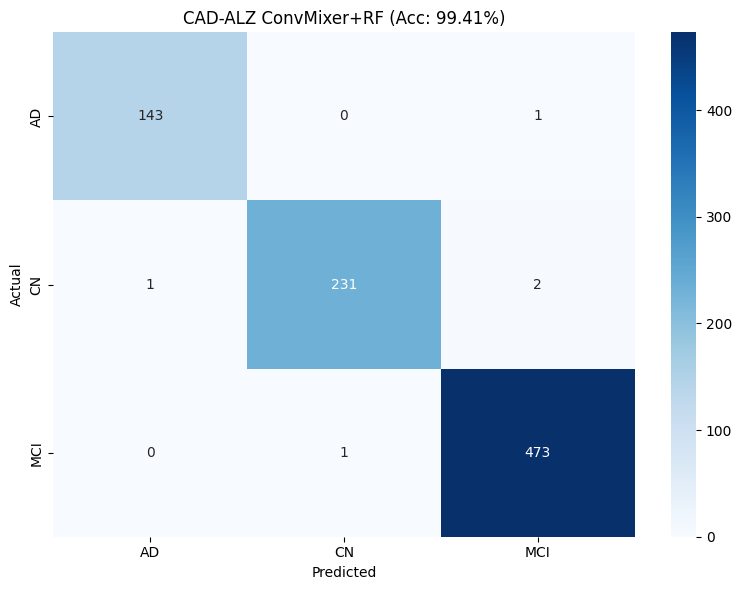


--- CNN Head (without RF) ---


CNN-only Test Accuracy: 99.65%
              precision    recall  f1-score   support

          AD     0.9931    0.9931    0.9931       144
          CN     1.0000    0.9957    0.9979       234
         MCI     0.9958    0.9979    0.9968       474

    accuracy                         0.9965       852
   macro avg     0.9963    0.9956    0.9959       852
weighted avg     0.9965    0.9965    0.9965       852



In [36]:
print("\nClassification Report (ConvMixer + RF):")
print("="*60)
print(classification_report(y_test, rf_preds, target_names=CLASS_NAMES, digits=4))

precision, recall, f1, support = precision_recall_fscore_support(y_test, rf_preds, average=None, zero_division=0)
macro_f1 = np.mean(f1)
weighted_f1 = np.average(f1, weights=support)
print(f"Macro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}")

cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'CAD-ALZ ConvMixer+RF (Acc: {rf_acc*100:.2f}%)')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "cm_cadalz_multiclass.png"), dpi=150)
plt.show()

print("\n--- CNN Head (without RF) ---")
_, cnn_acc, cnn_preds, cnn_labels = run_epoch(test_loader, model, criterion, desc="CNN Test")
print(f"CNN-only Test Accuracy: {cnn_acc*100:.2f}%")
print(classification_report(cnn_labels, cnn_preds, target_names=CLASS_NAMES, digits=4))

In [37]:
!pip install grad-cam lime shap

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
import shap
import os
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from lime import lime_image
from skimage.segmentation import mark_boundaries

def normalize_image(image_array):
    img = np.array(image_array, dtype=np.float32)
    img = img - np.min(img)
    if np.max(img) > 0: img = img / np.max(img)
    return img

def convert_to_rgb(image_array):
    if len(image_array.shape) == 2: return np.stack([image_array] * 3, axis=-1)
    elif image_array.shape[0] == 3: return np.transpose(image_array, (1, 2, 0))
    return image_array

def create_colormap_overlay(heatmap, image_array, alpha=0.4, colormap='jet'):
    heatmap = normalize_image(heatmap)
    image_array = normalize_image(image_array)
    if len(image_array.shape) == 2: image_array = convert_to_rgb(image_array)
    heatmap_colored = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    return (1 - alpha) * image_array + alpha * heatmap_colored

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.6 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=2a92586302ee67bddfd1f93d0dc689b067038c7a79679a49f9b1160111c8e020
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [38]:
def compute_gradcam(model, image_tensor, target_class, device='cuda'):
    model = model.to(device)
    model.eval()
    
    target_layer = model.backbone.blocks[-1]
    
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(
        input_tensor=image_tensor.to(device),
        targets=[ClassifierOutputTarget(target_class)],
        eigen_smooth=False, aug_smooth=False
    )
    
    with torch.no_grad():
        output = model(image_tensor.to(device))
        pred_prob = torch.softmax(output, dim=1)[0, target_class].item()
        pred_class = output.argmax(dim=1).item()
    
    return grayscale_cam[0], pred_class, pred_prob

def visualize_gradcam(image_array, grayscale_cam, pred_class, pred_prob, target_class, class_names, title):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    image_array = convert_to_rgb(normalize_image(image_array))
    grayscale_cam = normalize_image(grayscale_cam)
    
    axes[0].imshow(image_array, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    im = axes[1].imshow(grayscale_cam, cmap='hot')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    overlay = create_colormap_overlay(grayscale_cam, image_array, alpha=0.5)
    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay\n(Target: {class_names[target_class]}, Pred: {class_names[pred_class]} {pred_prob:.2%})')
    axes[2].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

def compute_lime_explanation(model, image_array, target_class, device='cuda'):
    model = model.to(device)
    model.eval()
    image_array = convert_to_rgb(normalize_image(image_array))
    
    def predict_fn(images):
        imgs = torch.from_numpy(images).float().permute(0, 3, 1, 2).to(device)
        with torch.no_grad():
            return torch.softmax(model(imgs), dim=1).cpu().numpy()

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        image=image_array, classifier_fn=predict_fn, labels=[target_class], num_samples=500
    )
    image_and_mask = explanation.get_image_and_mask(label=target_class, positive_only=False, num_features=5, hide_rest=False)
    return explanation, image_and_mask

def visualize_lime(image_array, explanation, image_and_mask, target_class, class_names, title):
    image_array = convert_to_rgb(normalize_image(image_array))
    image, mask = image_and_mask
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(image_array)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    pos_image, _ = explanation.get_image_and_mask(target_class, positive_only=True, hide_rest=False)
    axes[1].imshow(mark_boundaries(pos_image, mask))
    axes[1].set_title(f'LIME Supporting Regions ({class_names[target_class]})')
    axes[1].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig


1. SHAP Analysis (Explaining the Random Forest)


/tmp/ipykernel_57/3414803996.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


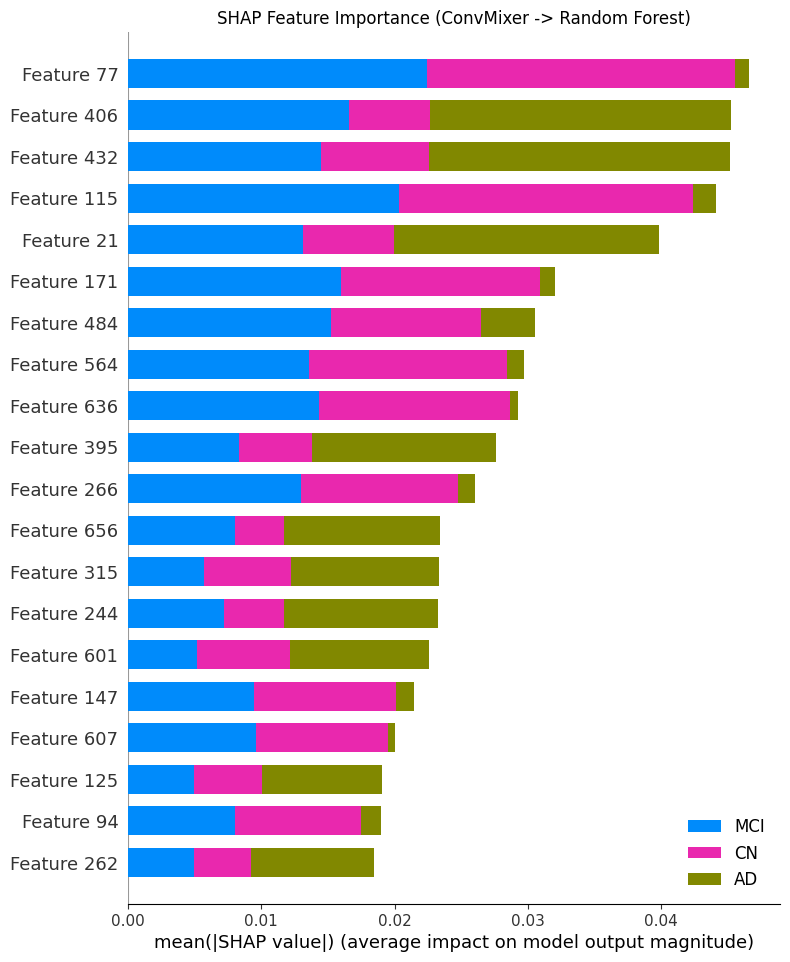

In [44]:
print("\n" + "="*60)
print("1. SHAP Analysis (Explaining the Random Forest)")
print("="*60)

explainer = shap.TreeExplainer(rf)
sample_idx = np.random.choice(X_test.shape[0], min(200, X_test.shape[0]), replace=False)
shap_values = explainer.shap_values(X_test[sample_idx])

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    X_test[sample_idx], 
    class_names=CLASS_NAMES, 
    plot_type="bar", 
    show=False
)
plt.title("SHAP Feature Importance (ConvMixer -> Random Forest)")
plt.savefig(os.path.join(CKPT_DIR, "shap_convmixer_rf.png"), dpi=150)
plt.show()

In [40]:
print("Extracting New Random Test Samples...")

model.eval()
xai_samples = {}
temp_loader = torch.utils.data.DataLoader(test_loader.dataset, batch_size=1, shuffle=True)

for images, labels in temp_loader:
    lbl = labels[0].item()
    if lbl not in xai_samples:
        img_tensor = images.to(device)
        img_array = images[0].cpu().numpy()
        xai_samples[lbl] = (img_tensor, img_array)
    if len(xai_samples) == len(CLASS_NAMES): break

print(f"Successfully extracted {len(xai_samples)} NEW images (1 per class).")

Extracting New Random Test Samples...
Successfully extracted 3 NEW images (1 per class).



2. Grad-CAM (Explaining the ConvMixer)

--- Grad-CAM Class: AD ---


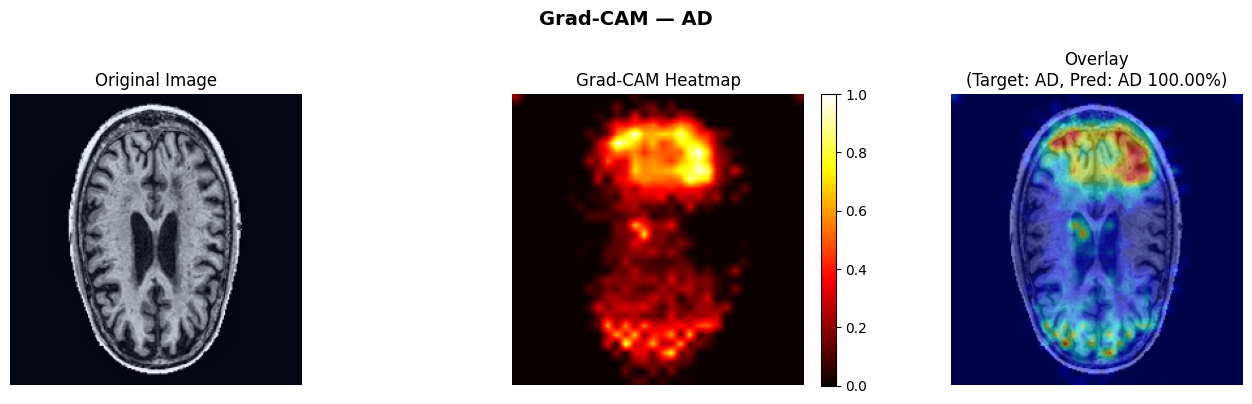


--- Grad-CAM Class: CN ---


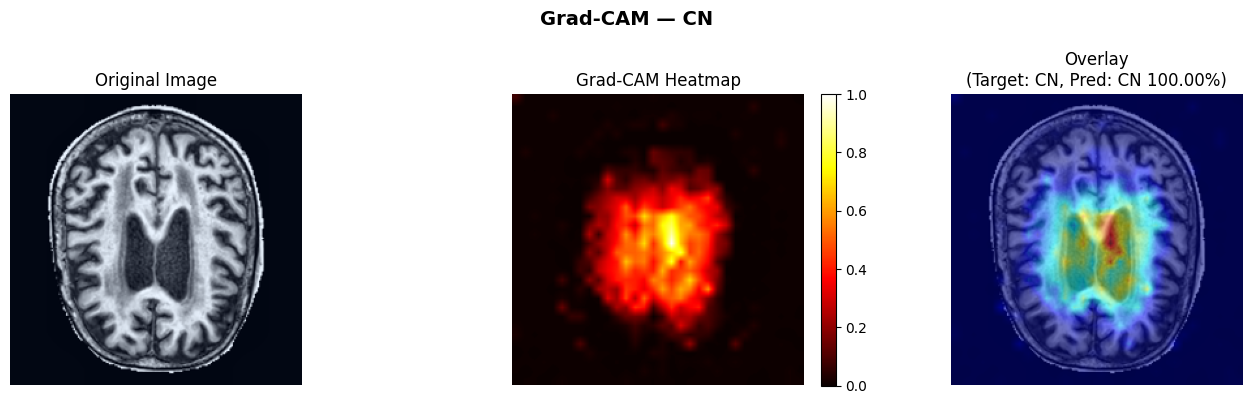


--- Grad-CAM Class: MCI ---


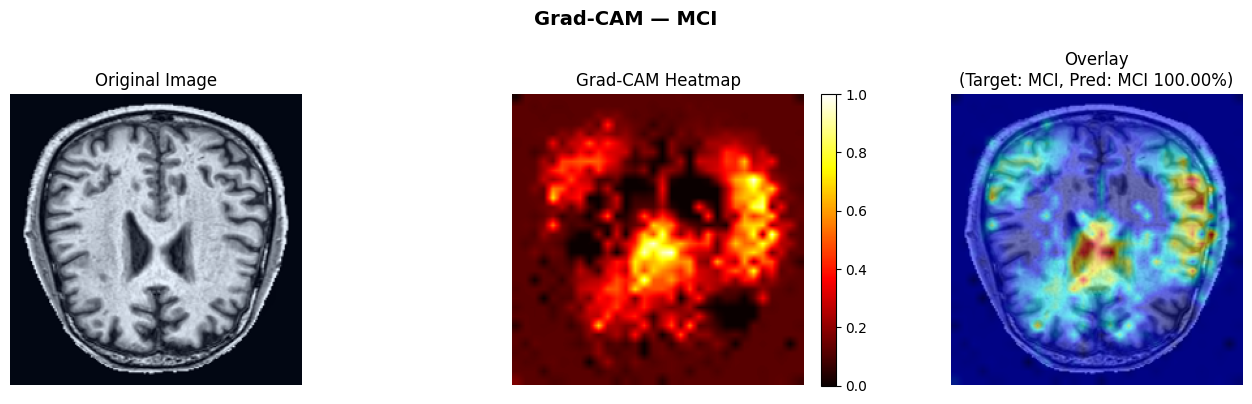

In [41]:
print("\n" + "="*60)
print("2. Grad-CAM (Explaining the ConvMixer)")
print("="*60)

for cls_idx in sorted(xai_samples):
    img_tensor, img_array = xai_samples[cls_idx]
    
    print(f'\n--- Grad-CAM Class: {CLASS_NAMES[cls_idx]} ---')
    cam, pred_class, pred_prob = compute_gradcam(model, img_tensor, cls_idx, device)
    fig_cam = visualize_gradcam(img_array, cam, pred_class, pred_prob, cls_idx, CLASS_NAMES, f'Grad-CAM — {CLASS_NAMES[cls_idx]}')
    plt.show()

## 4. Occlusion Sensitivity (Explaining the ConvMixer)

We slide a small grey patch across the image and measure how much the predicted probability for the target class drops. Regions that cause the largest drop are the regions the model relies on most.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def occlusion_sensitivity(model, image_tensor, target_class,
                          patch_size=24, stride=12, occlusion_value=0.0,
                          device='cuda'):
    model = model.to(device).eval()
    x = image_tensor.to(device).clone()
    _, _, H, W = x.shape
    base_prob = torch.softmax(model(x), dim=1)[0, target_class].item()
    heat = np.zeros((H, W), dtype=np.float32)
    counts = np.zeros((H, W), dtype=np.float32)
    for y in range(0, H, stride):
        for xx in range(0, W, stride):
            y0, y1 = y, min(y + patch_size, H)
            x0, x1 = xx, min(xx + patch_size, W)
            occ = x.clone()
            occ[:, :, y0:y1, x0:x1] = occlusion_value
            p = torch.softmax(model(occ), dim=1)[0, target_class].item()
            heat[y0:y1, x0:x1] += (base_prob - p)
            counts[y0:y1, x0:x1] += 1.0
    heat = heat / np.maximum(counts, 1.0)
    return heat, base_prob

def visualize_occlusion(image_array, heat, base_prob, target_class, class_names, title):
    img = convert_to_rgb(normalize_image(image_array))
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img); axes[0].set_title('Original'); axes[0].axis('off')
    im = axes[1].imshow(heat, cmap='hot')
    axes[1].set_title('Occlusion drop in target prob.'); axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    axes[2].imshow(create_colormap_overlay(heat, img, alpha=0.5))
    axes[2].set_title(f'Overlay (target={class_names[target_class]}, p={base_prob:.2%})')
    axes[2].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

print("\n" + "="*60)
print("4. Occlusion Sensitivity (Explaining the ConvMixer)")
print("="*60)

for cls_idx in sorted(xai_samples):
    img_tensor, img_array = xai_samples[cls_idx]
    print(f'\n--- Occlusion Class: {CLASS_NAMES[cls_idx]} ---')
    heat, base_prob = occlusion_sensitivity(model, img_tensor, cls_idx,
                                           patch_size=24, stride=12, device=device)
    visualize_occlusion(img_array, heat, base_prob, cls_idx, CLASS_NAMES,
                        f'Occlusion Sensitivity — {CLASS_NAMES[cls_idx]}')
    plt.show()
